## Plan
- Load pickle file - Model Files/patient_risk_model.pkl
- Evaluate on training and test data and generate confusion matrix, precision, recall & F1 Score
- Generate feature importance and explainability summaries
- Segment performance by gender, city and insurance provider

In [9]:
import pandas as pd
from pycaret.classification import load_model
import json
from sklearn.metrics import confusion_matrix, classification_report
import shap

In [10]:
# Load picke file from Model Files/patient_risk_model.pkl
model_name = "../../Model Files/patient_risk_model"
risk_model = load_model(model_name)

# Read model_table.csv and sort by visit_date
DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])
df = df.sort_values("visit_date").reset_index(drop=True)

# Read model feature json file from Model Files/patient_risk_model_feature_schema.json
FEATURES_PATH = "../../Model Files/patient_risk_model_feature_schema.json"
with open(FEATURES_PATH, "r") as f:
    model_features = [feat["name"] for feat in json.load(f)["features"]]

# Create a df only for those features + target
columns_to_keep = model_features + ["risk_score", "visit_date"]
df = df[columns_to_keep]

# Create x and y for the model 80:20 split no shuffling
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]




Transformation Pipeline and Model Successfully Loaded


In [11]:
# Confusion matrices and precision, recall, and F1-score for the test set
y_true = test_df["risk_score"]
X_test = test_df.drop(columns=["risk_score", "visit_date"])
y_pred = risk_model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))    


Confusion Matrix:
[[412 272 339]
 [931 787 762]
 [561 477 459]]

Classification Report:
              precision    recall  f1-score   support

        High       0.22      0.40      0.28      1023
         Low       0.51      0.32      0.39      2480
      Medium       0.29      0.31      0.30      1497

    accuracy                           0.33      5000
   macro avg       0.34      0.34      0.32      5000
weighted avg       0.39      0.33      0.34      5000



In [12]:
# Showcase feature importance for the risk model
print("\nFeature Importance for the Risk Model:")
importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": risk_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance_df)   


Feature Importance for the Risk Model:
           Feature  Importance
1           gender    0.341791
2  visit_frequency    0.340335
0     chronic_flag    0.317874


In [13]:
# Generate explanations for a few test samples using SHAP

print("\nGenerating SHAP explanations for test samples...")

final_estimator = risk_model.steps[-1][1]
X_test_transformed = risk_model[:-1].transform(X_test)

background = shap.sample(X_test_transformed, 100, random_state=42)
sample = X_test_transformed.iloc[:50]

explainer = shap.Explainer(final_estimator.predict_proba, background)
shap_values = explainer(sample)



Generating SHAP explanations for test samples...


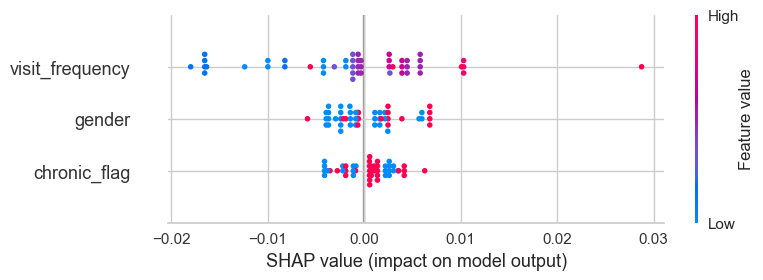

In [14]:
shap.plots.beeswarm(shap_values[:, :, 1])

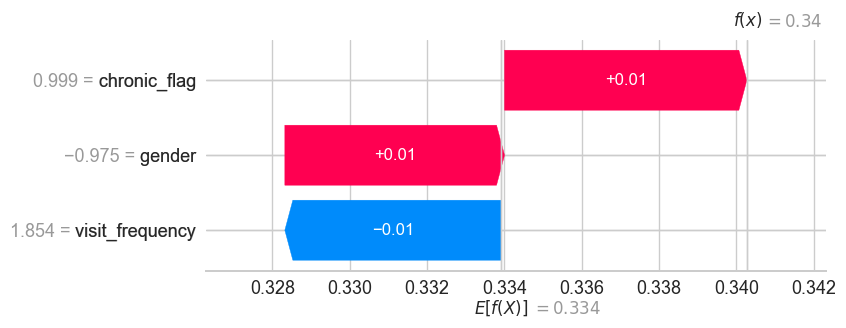

In [15]:
shap.plots.waterfall(shap_values[0, :, 1])

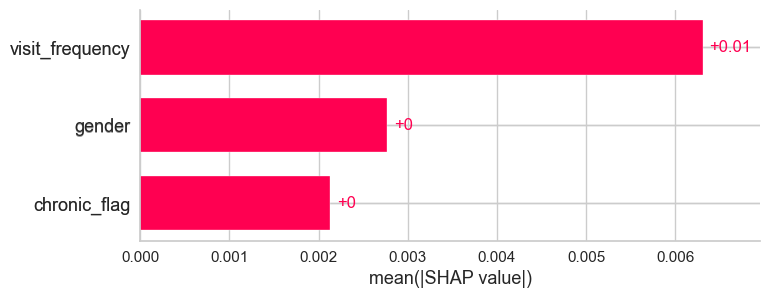

In [16]:
shap.plots.bar(shap_values[:, :, 1])

Transformation Pipeline and Model Successfully Loaded


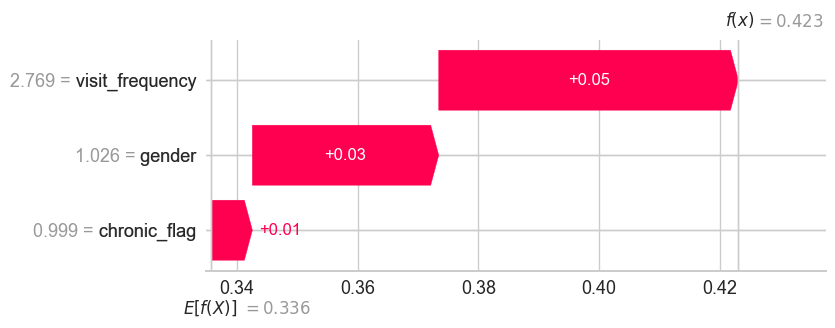

In [ ]:
DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])

# Sort by visit_date immediately — ensures temporal order for all downstream operations
df = df.sort_values("visit_date").reset_index(drop=True)


lean_columns = ["chronic_flag", "gender", "visit_frequency"]

# df is already sorted by visit_date (done at load time) — no shuffling, no data leakage
data_lean = df[lean_columns]

# Load the pipeline and extract the components
production_model = load_model("../../Model Files/patient_risk_model")
prep_pipeline = production_model[:-1]
raw_xgb = production_model.steps[-1][1]

# Create the synthetic background dataset
synthetic_background_raw = pd.DataFrame([
    {"chronic_flag": 0, "gender": "M", "visit_frequency": 1},
    {"chronic_flag": 0, "gender": "F", "visit_frequency": 2},
    {"chronic_flag": 1, "gender": "M", "visit_frequency": 5},
    {"chronic_flag": 1, "gender": "F", "visit_frequency": 8},
    {"chronic_flag": 1, "gender": "M", "visit_frequency": 15},
    {"chronic_flag": 0, "gender": "F", "visit_frequency": 0}
])


# This converts "M" and "F" into numbers so SHAP doesn't crash
background_transformed = prep_pipeline.transform(data_lean.sample(100, random_state=42))

# Create the Black-Box Explainer
explainer = shap.Explainer(raw_xgb.predict_proba, background_transformed)


# --- IN PRODUCTION WHEN A PATIENT ARRIVES ---


# 5. New patient arrives (Raw Data)
new_patient_raw = pd.DataFrame([{"chronic_flag": 1, "gender": "M", "visit_frequency": 12}])

# 6. Transform the new patient data
new_patient_transformed = prep_pipeline.transform(new_patient_raw)

# 7. Generate SHAP values
shap_values_new = explainer(new_patient_transformed)


# 8. Plot the Waterfall for Class 2 (High Risk)
shap.plots.waterfall(shap_values_new[0, :, 2])